In [ ]:
import os
import requests

os.makedirs("data/nyc_taxi", exist_ok=True)

years = range(2024, 2026)
months = [f"{m:02d}" for m in range(1, 13)]

for y in years:
    for m in months:

        fname = f"yellow_tripdata_{y}-{m}.parquet"
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/{fname}"

        output_path = os.path.join(
            "data",
            "nyc_taxi",
            fname
        )

        try:

            response = requests.get(
                url,
                stream=True,
                timeout=30
            )

            if response.status_code == 200:

                with open(output_path, "wb") as f:
                    for chunk in response.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if chunk:
                            f.write(chunk)

                print(f"Downloaded: {fname}")

            else:
                print(f"Not found: {fname}")

        except Exception as e:
            print(f"Error downloading {fname}: {e}")

Downloaded: yellow_tripdata_2024-01.parquet
Downloaded: yellow_tripdata_2024-02.parquet
Downloaded: yellow_tripdata_2024-03.parquet
Downloaded: yellow_tripdata_2024-04.parquet
Downloaded: yellow_tripdata_2024-05.parquet
Downloaded: yellow_tripdata_2024-06.parquet
Downloaded: yellow_tripdata_2024-07.parquet
Downloaded: yellow_tripdata_2024-08.parquet
Downloaded: yellow_tripdata_2024-09.parquet
Downloaded: yellow_tripdata_2024-10.parquet
Downloaded: yellow_tripdata_2024-11.parquet
Downloaded: yellow_tripdata_2024-12.parquet
Downloaded: yellow_tripdata_2025-01.parquet
Downloaded: yellow_tripdata_2025-02.parquet
Downloaded: yellow_tripdata_2025-03.parquet
Downloaded: yellow_tripdata_2025-04.parquet
Downloaded: yellow_tripdata_2025-05.parquet
Downloaded: yellow_tripdata_2025-06.parquet
Downloaded: yellow_tripdata_2025-07.parquet
Downloaded: yellow_tripdata_2025-08.parquet
Downloaded: yellow_tripdata_2025-09.parquet
Downloaded: yellow_tripdata_2025-10.parquet
Downloaded: yellow_tripdata_2025

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analysis")
    .getOrCreate()
)

print("Spark started successfully")

Spark started successfully


In [ ]:
folder = "data/nyc_taxi"

paths = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith(".parquet")
]

raw_df = spark.read.parquet(*paths)

print(f"Raw dataset rows: {raw_df.count():,}")

Raw dataset rows: 89,892,322


In [ ]:
from pyspark.sql.functions import col

def load_and_cast(path):

    df = spark.read.parquet(path)

    return (
        df
        .withColumn("VendorID", col("VendorID").cast("int"))
        .withColumn("passenger_count", col("passenger_count").cast("int"))
        .withColumn("RatecodeID", col("RatecodeID").cast("int"))
        .withColumn("PULocationID", col("PULocationID").cast("int"))
        .withColumn("DOLocationID", col("DOLocationID").cast("int"))
        .withColumnRenamed("Airport_fee", "airport_fee")
    )

In [ ]:
dfs = [load_and_cast(path) for path in paths]

processing_df = dfs[0]

for df in dfs[1:]:
    processing_df = processing_df.unionByName(
        df,
        allowMissingColumns=True
    )

In [ ]:
from pyspark.sql.functions import year

processing_df = (
    processing_df
    .filter(
        (col("tpep_pickup_datetime").isNotNull())
        &
        (col("tpep_dropoff_datetime").isNotNull())
    )
    .filter(col("fare_amount") > 0)
    .dropDuplicates()
    .filter(col("trip_distance") < 100)
    .filter(
        (year(col("tpep_pickup_datetime")) >= 2024)
        &
        (year(col("tpep_pickup_datetime")) <= 2025)
    )
)

In [ ]:
# extra cleaning, cache, and Spark config
import io, time, contextlib
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, when, sum as spark_sum

spark.conf.set("spark.sql.shuffle.partitions", "64")   # default 200 is too many for small aggregates

processing_df = (
    processing_df
    .filter(col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
    .filter(col("trip_distance") > 0)
    .persist()                       # cache: dropDuplicates() shuffle runs only once
)
row_count_processing = processing_df.count()          # action: materialises the cache
print(f"Processing rows after extra filters: {row_count_processing:,}")

# Sizes for the report (working vs processing)
os.system("du -sh data/nyc_taxi")                      # on-disk size of the 24 Parquet files
print("Raw rows:", f"{raw_df.count():,}")

Processing rows after extra filters: 83,872,424
Raw rows: 89,892,322


In [ ]:
# MAP / TRANSFORMATION (narrow transformations, no shuffle)
mapped_df = (
    processing_df
    .withColumn("trip_category",
        when(col("trip_distance") < 2, "Short")
        .when(col("trip_distance") < 10, "Medium")
        .otherwise("Long"))
    .withColumn("hour", F.hour("tpep_pickup_datetime"))
    .withColumn("is_weekend", F.dayofweek("tpep_pickup_datetime").isin(1, 7))
    .withColumn("minutes",
        (F.unix_timestamp("tpep_dropoff_datetime") -
         F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((col("minutes") > 1) & (col("minutes") < 360))
    .persist()
)
print(f"Mapped rows: {mapped_df.count():,}")


Mapped rows: 83,569,178


In [ ]:
# CLASSIC MAPREDUCE with RDDs (10% sample; Python RDDs can be slow on 86M rows)
t0 = time.time()
pairs = (
    mapped_df.sample(False, 0.1, 42)
    .select("PULocationID", "hour", "fare_amount", "trip_distance", "minutes").rdd
    .map(lambda r: ((r.PULocationID, r.hour),
                    (1, r.fare_amount, r.trip_distance, r.minutes)))      # MAP: emit key-value
)
agg_rdd = pairs.reduceByKey(lambda a, b: tuple(x + y for x, y in zip(a, b)))  # SHUFFLE + REDUCE
rdd_top = (agg_rdd
           .map(lambda kv: (kv[0][0], kv[0][1], kv[1][0], kv[1][1] / kv[1][3]))  # zone, hour, trips, fare/min
           .takeOrdered(10, key=lambda x: -x[2]))
print("RDD top 10 (zone, hour, sample trips, fare per minute):")
for row in rdd_top:
    print(row)
print(f"RDD job time: {time.time() - t0:.1f}s")
print("RDD lineage:\n", agg_rdd.toDebugString().decode())   # shows ShuffledRDD = stage boundary


RDD top 10 (zone, hour, sample trips, fare per minute):
(161, 18, 33425, 1.0043005464500103)
(161, 17, 32628, 0.9808291199123199)
(237, 14, 30145, 1.0264481377780024)
(237, 15, 29979, 1.012116175398522)
(237, 17, 29493, 1.0327769221292067)
(237, 18, 29292, 1.0641837140473556)
(161, 19, 29013, 1.043754969810517)
(237, 16, 28411, 1.8976507092643455)
(132, 16, 28411, 1.3703941363449679)
(161, 16, 28182, 0.9893222393940165)
RDD job time: 110.3s
RDD lineage:
 (64) PythonRDD[329] at RDD at PythonRDD.scala:57 []
 |   MapPartitionsRDD[327] at mapPartitions at PythonRDD.scala:169 []
 |   ShuffledRDD[326] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(64) PairwiseRDD[325] at reduceByKey at /tmp/ipykernel_2832/3034583849.py:9 []
    |   PythonRDD[324] at reduceByKey at /tmp/ipykernel_2832/3034583849.py:9 []
    |   MapPartitionsRDD[323] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   MapPartitionsRDD[322] at javaToPython at NativeMethodAccessorImpl.java:0 []
    |   SQLExe

In [ ]:
# SHUFFLE + REDUCE, segments
revenue_results = (
    mapped_df.groupBy("trip_category")
    .agg(count("*").alias("trip_count"),
         avg("fare_amount").alias("avg_fare"),
         spark_sum("fare_amount").alias("total_revenue"),
         (spark_sum("fare_amount") / spark_sum("minutes")).alias("fare_per_min"),
         (spark_sum("fare_amount") / spark_sum("trip_distance")).alias("fare_per_mile"))
)
tot_rev   = revenue_results.agg(spark_sum("total_revenue")).collect()[0][0]
tot_trips = revenue_results.agg(spark_sum("trip_count")).collect()[0][0]
revenue_results = (revenue_results
    .withColumn("revenue_pct", col("total_revenue") / tot_rev * 100)
    .withColumn("trip_pct",    col("trip_count") / tot_trips * 100))
revenue_results.show(truncate=False)

# Correlation computed in Spark on ALL rows (not a Pandas sample)
print("corr(distance, fare):", mapped_df.stat.corr("trip_distance", "fare_amount"))


+-------------+----------+------------------+--------------------+------------------+-----------------+------------------+-----------------+
|trip_category|trip_count|avg_fare          |total_revenue       |fare_per_min      |fare_per_mile    |revenue_pct       |trip_pct         |
+-------------+----------+------------------+--------------------+------------------+-----------------+------------------+-----------------+
|Short        |44642463  |10.620700855818624|4.7413424498995125E8|1.0995108777598412|9.326150483271354|28.516781351795682|53.41977038472246|
|Medium       |32138695  |23.420557142409972|7.527061427299857E8 |1.1000447177437795|5.719496232708354|45.27147473779169 |38.45759377937162|
|Long         |6788020   |64.2027486071046  |4.358095415999981E8 |1.3748225551361588|4.058831899776214|26.211743910412643|8.122635835905912|
+-------------+----------+------------------+--------------------+------------------+-----------------+------------------+-----------------+

corr(distanc

In [ ]:
# hour profile, monthly trend, payment labels (all Spark aggregations)
hour_results = (
    mapped_df.groupBy("hour", "is_weekend")
    .agg(count("*").alias("trips"),
         (spark_sum("fare_amount") / spark_sum("minutes")).alias("fare_per_min"))
    .orderBy("hour", "is_weekend")
)

monthly_results = (
    mapped_df
    .groupBy(F.year("tpep_pickup_datetime").alias("year"),
             F.month("tpep_pickup_datetime").alias("month"))
    .agg(count("*").alias("trip_count"),
         avg("fare_amount").alias("avg_fare"),
         spark_sum("fare_amount").alias("revenue"))
    .orderBy("year", "month")
)
monthly_results.show(24, truncate=False)          # 24 rows, not the default 20

pay_labels = {0: "Flex Fare", 1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided"}
payment_results = (
    mapped_df.groupBy("payment_type")
    .agg(count("*").alias("trip_count"), avg("fare_amount").alias("avg_fare"))
    .orderBy(col("trip_count").desc())
)
payment_pd = payment_results.toPandas()
payment_pd["label"] = payment_pd["payment_type"].map(pay_labels)
payment_pd["pct"] = payment_pd["trip_count"] / payment_pd["trip_count"].sum() * 100
print(payment_pd)


+----+-----+----------+------------------+--------------------+
|year|month|trip_count|avg_fare          |revenue             |
+----+-----+----------+------------------+--------------------+
|2024|1    |2858972   |18.452025423823613|5.2753824029999845E7|
|2024|2    |2891163   |18.380422912855455|5.314079864999992E7 |
|2024|3    |3427429   |19.11787026368734 |6.5525142959999636E7|
|2024|4    |3401918   |19.416013825142073|6.6051686919999674E7|
|2024|5    |3603437   |20.105979921391782|7.245063197000024E7 |
|2024|6    |3415468   |19.905656791397224|6.798713378999989E7 |
|2024|7    |2961720   |20.107388014397003|5.955245322999989E7 |
|2024|8    |2855177   |20.31780825146742 |5.801093880999999E7 |
|2024|9    |3470524   |20.605447534723865|7.15117002E7        |
|2024|10   |3668365   |20.31932732429845 |7.453870918000008E7 |
|2024|11   |3496881   |19.7874523125036  |6.91943660299999E7  |
|2024|12   |3504921   |20.34368118140189 |7.13029953900003E7  |
|2025|1    |3241636   |18.18053910741375

In [ ]:
# JOIN with zone lookup + zone x hour aggregation (the main shuffle)
import requests
os.makedirs("data", exist_ok=True)
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
with open("data/taxi_zone_lookup.csv", "wb") as f:
    f.write(requests.get(zone_url, timeout=30).content)
zones = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)

t0 = time.time()
zone_hour = (
    mapped_df.groupBy("PULocationID", "hour")
    .agg(count("*").alias("trips"),
         spark_sum("fare_amount").alias("fare_revenue"),
         (spark_sum("fare_amount") / spark_sum("minutes")).alias("fare_per_min"),
         (spark_sum("fare_amount") / spark_sum("trip_distance")).alias("fare_per_mile"))
    .join(F.broadcast(zones), col("PULocationID") == zones.LocationID)   # broadcast join: no shuffle of big side
    .select("Borough", "Zone", "PULocationID", "hour", "trips", "fare_revenue", "fare_per_min", "fare_per_mile")
    .persist()
)
n = zone_hour.count()
print(f"zone x hour rows: {n:,}  | job time: {time.time() - t0:.1f}s")

zone_totals = (
    zone_hour.groupBy("Borough", "Zone")
    .agg(spark_sum("trips").alias("trips"),
         spark_sum("fare_revenue").alias("fare_revenue"),
         (spark_sum("fare_revenue") / spark_sum("trips")).alias("avg_fare"))
    .orderBy(col("trips").desc())
)
zone_totals.show(15, truncate=False)

# Best-paid zone-hours, with a minimum volume so tiny groups don't dominate
zone_hour.filter(col("trips") > 5000).orderBy(col("fare_per_min").desc()).show(15, truncate=False)

borough_hour = zone_hour.groupBy("Borough", "hour").agg(spark_sum("trips").alias("trips"))


zone x hour rows: 6,191  | job time: 39.2s
+---------+----------------------------+-------+--------------------+------------------+
|Borough  |Zone                        |trips  |fare_revenue        |avg_fare          |
+---------+----------------------------+-------+--------------------+------------------+
|Manhattan|Upper East Side South       |3861909|5.174274222000001E7 |13.398229274692907|
|Manhattan|Midtown Center              |3799169|6.416935546E7       |16.890366145859794|
|Queens   |JFK Airport                 |3705226|2.3726819497000003E8|64.03609252714949 |
|Manhattan|Upper East Side North       |3429660|4.729432205000001E7 |13.789799003399757|
|Manhattan|Midtown East                |2787666|4.5078156599999994E7|16.17057301699701 |
|Manhattan|Penn Station/Madison Sq West|2763005|4.775483709E7       |17.283659309338926|
|Manhattan|Times Sq/Theatre District   |2723252|5.3329466529999994E7|19.58300830404237 |
|Manhattan|Lincoln Square East         |2562442|3.756829640999999E7

In [ ]:
# EXECUTION EVIDENCE (paste this output into the report)
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    zone_hour.explain("formatted")
plan = buf.getvalue()
print(plan)                                   # look for: HashAggregate(partial), Exchange hashpartitioning, HashAggregate(final), BroadcastHashJoin
os.makedirs("output", exist_ok=True)
open("output/zone_hour_explain.txt", "w").write(plan)

# Spark UI. In Colab it is NOT reachable. Options:
#  (a) run this notebook locally (pip install pyspark) and open http://localhost:4040
#      -> screenshot the Jobs, Stages and "DAG Visualization" tabs after running CELL 6
#  (b) in Colab, print stage metrics instead:
tracker = spark.sparkContext.statusTracker()
for sid in tracker.getActiveStageIds() + []:
    print(tracker.getStageInfo(sid))
print("Spark UI URL (local runs):", spark.sparkContext.uiWebUrl)


== Physical Plan ==
AdaptiveSparkPlan (191)
+- InMemoryTableScan (1)
      +- InMemoryRelation (2)
            +- AdaptiveSparkPlan (190)
               +- == Final Plan ==
                  ResultQueryStage (181)
                  +- * Project (180)
                     +- * BroadcastHashJoin Inner BuildRight (179)
                        :- * HashAggregate (174)
                        :  +- ShuffleQueryStage (173), Statistics(sizeInBytes=18.4 MiB, rowCount=3.45E+5)
                        :     +- Exchange (172)
                        :        +- * HashAggregate (171)
                        :           +- * Filter (170)
                        :              +- TableCacheQueryStage (169), Statistics(sizeInBytes=12.1 GiB, rowCount=8.36E+7)
                        :                 +- InMemoryTableScan (3)
                        :                       +- InMemoryRelation (4)
                        :                             +- AdaptiveSparkPlan (168)
                          

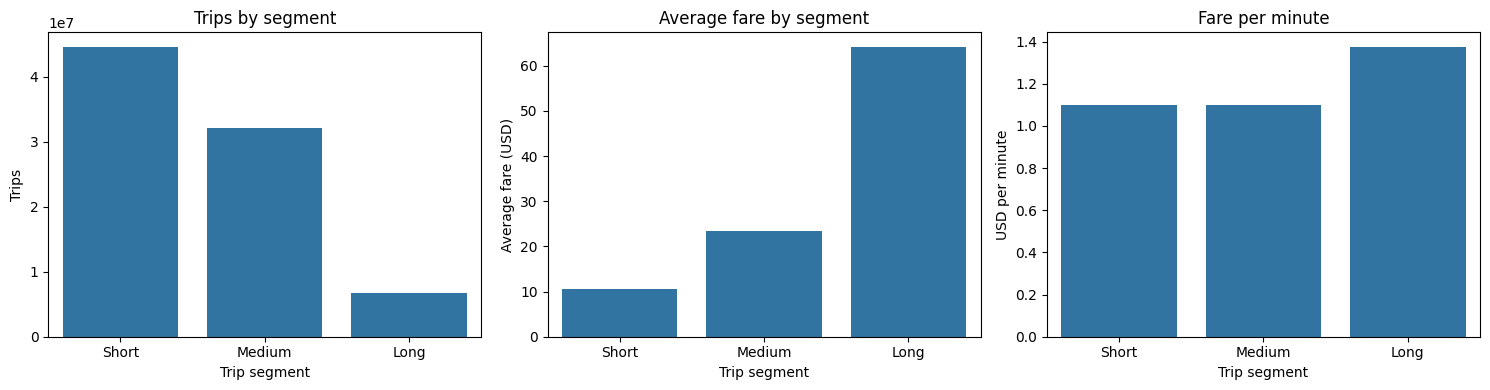

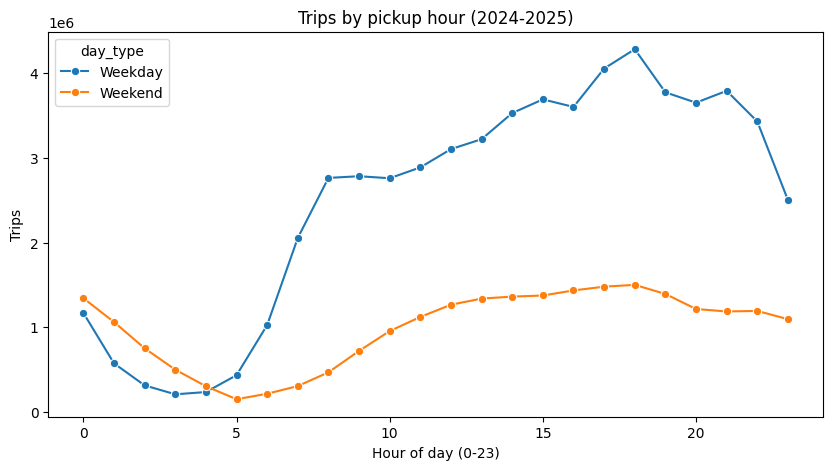

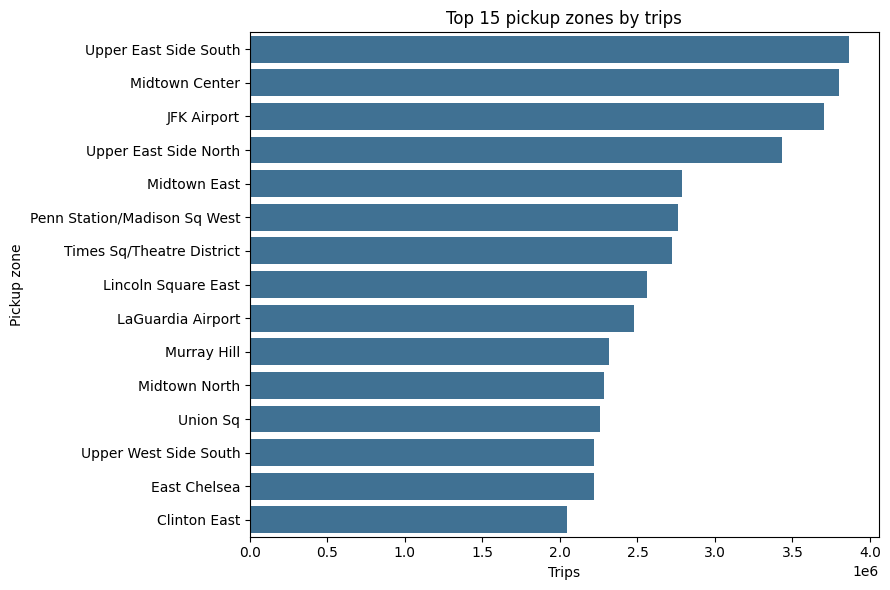

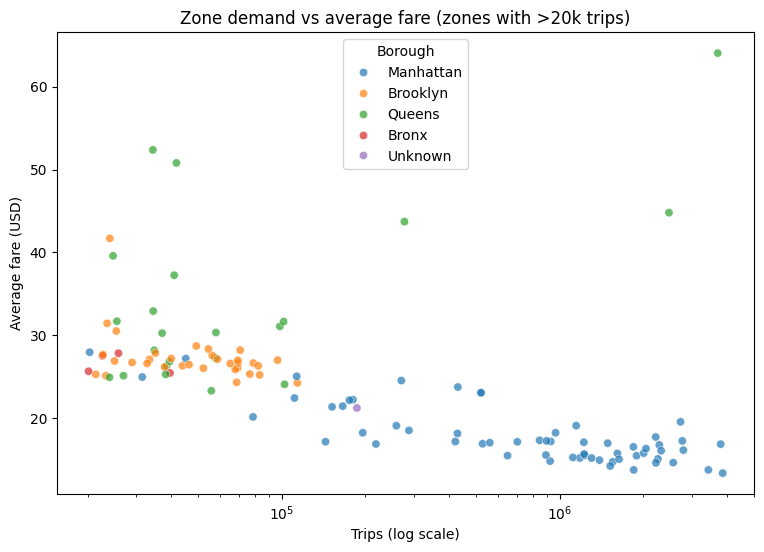

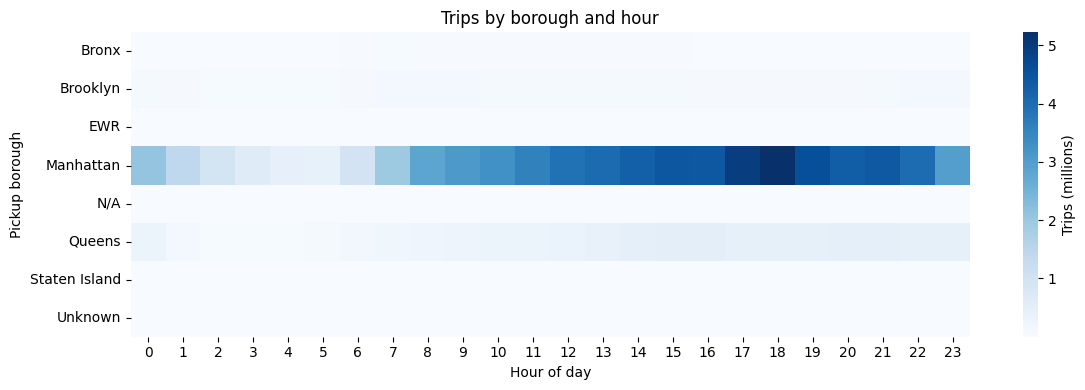

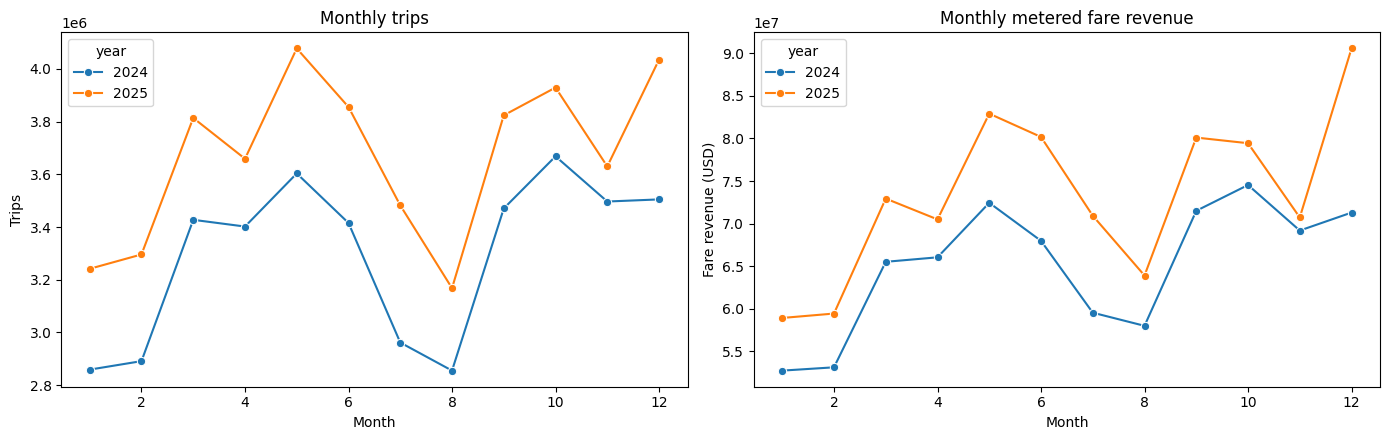

In [ ]:
# VISUALISATION (Pandas only on SMALL aggregated results)
import matplotlib.pyplot as plt
import seaborn as sns
os.makedirs("figures", exist_ok=True)
order = ["Short", "Medium", "Long"]
rev_pd = revenue_results.toPandas().set_index("trip_category").loc[order].reset_index()

# Fig 1: segment trips vs avg fare vs fare/min
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=rev_pd, x="trip_category", y="trip_count", ax=ax[0]);   ax[0].set_title("Trips by segment");        ax[0].set_ylabel("Trips")
sns.barplot(data=rev_pd, x="trip_category", y="avg_fare", ax=ax[1]);     ax[1].set_title("Average fare by segment"); ax[1].set_ylabel("Average fare (USD)")
sns.barplot(data=rev_pd, x="trip_category", y="fare_per_min", ax=ax[2]); ax[2].set_title("Fare per minute");          ax[2].set_ylabel("USD per minute")
for a in ax: a.set_xlabel("Trip segment")
plt.tight_layout(); plt.savefig("figures/fig1_segments.png", dpi=150); plt.show()

# Fig 2: trips by hour, weekday vs weekend
h = hour_results.toPandas()
h["day_type"] = h["is_weekend"].map({True: "Weekend", False: "Weekday"})
plt.figure(figsize=(10, 5))
sns.lineplot(data=h, x="hour", y="trips", hue="day_type", marker="o")
plt.title("Trips by pickup hour (2024-2025)"); plt.xlabel("Hour of day (0-23)"); plt.ylabel("Trips")
plt.savefig("figures/fig2_hourly.png", dpi=150); plt.show()

# Fig 3: top 15 zones
z = zone_totals.limit(15).toPandas()
plt.figure(figsize=(9, 6))
sns.barplot(data=z, y="Zone", x="trips", color="#3274a1")
plt.title("Top 15 pickup zones by trips"); plt.xlabel("Trips"); plt.ylabel("Pickup zone")
plt.tight_layout(); plt.savefig("figures/fig3_top_zones.png", dpi=150); plt.show()

# Fig 4: demand vs earning efficiency by zone
zs = (zone_hour.groupBy("Borough", "Zone")
      .agg(spark_sum("trips").alias("trips"),
           (spark_sum("fare_revenue") / spark_sum("trips")).alias("avg_fare"))
      .filter(col("trips") > 20000).toPandas())
plt.figure(figsize=(9, 6))
sns.scatterplot(data=zs, x="trips", y="avg_fare", hue="Borough", alpha=0.7)
plt.xscale("log"); plt.title("Zone demand vs average fare (zones with >20k trips)")
plt.xlabel("Trips (log scale)"); plt.ylabel("Average fare (USD)")
plt.savefig("figures/fig4_zone_scatter.png", dpi=150); plt.show()

# Fig 5: borough x hour heatmap
bh = borough_hour.toPandas().pivot(index="Borough", columns="hour", values="trips").fillna(0)
plt.figure(figsize=(12, 4))
sns.heatmap(bh / 1e6, cmap="Blues", cbar_kws={"label": "Trips (millions)"})
plt.title("Trips by borough and hour"); plt.xlabel("Hour of day"); plt.ylabel("Pickup borough")
plt.tight_layout(); plt.savefig("figures/fig5_borough_hour.png", dpi=150); plt.show()

# Fig 6: monthly trips and fare revenue
m = monthly_results.toPandas()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=m, x="month", y="trip_count", hue="year", marker="o", ax=ax[0], palette="tab10")
ax[0].set_title("Monthly trips"); ax[0].set_xlabel("Month"); ax[0].set_ylabel("Trips")
sns.lineplot(data=m, x="month", y="revenue", hue="year", marker="o", ax=ax[1], palette="tab10")
ax[1].set_title("Monthly metered fare revenue"); ax[1].set_xlabel("Month"); ax[1].set_ylabel("Fare revenue (USD)")
plt.tight_layout(); plt.savefig("figures/fig6_monthly.png", dpi=150); plt.show()

In [ ]:
# Dec 2025 check (explains the $22.8 average fare spike before you interpret it)
(mapped_df.filter((F.year("tpep_pickup_datetime") == 2025) & (F.month("tpep_pickup_datetime") >= 11))
 .groupBy(F.month("tpep_pickup_datetime").alias("month"), "trip_category")
 .agg(count("*").alias("trips"), avg("fare_amount").alias("avg_fare"))
 .orderBy("month", "trip_category").show())

+-----+-------------+-------+------------------+
|month|trip_category|  trips|          avg_fare|
+-----+-------------+-------+------------------+
|   11|         Long| 300821|61.026165826188986|
|   11|       Medium|1426136|22.384069282312485|
|   11|        Short|1903122|10.745432851913826|
|   12|         Long| 324273| 62.65845349443222|
|   12|       Medium|1623668| 27.04084788269494|
|   12|        Short|2087242|12.621876897839387|
+-----+-------------+-------+------------------+

